# Tutorial 5: Merger-tree building blocks

Galacticus grows galaxies inside dark-matter-halo *merger trees*. When
trees are not read from an N-body simulation they are built with the
extended Press-Schechter (EPS) formalism, where the linear collapse
threshold $\delta_\mathrm{c}(t)$ from Tutorial 3 plays the role of a
"time" variable: walking backwards to higher $\delta_\mathrm{c}$ (earlier
epochs), a halo's mass splits into progenitors at rates given by a
*branching probability* algorithm.

Building full trees is the job of a Galacticus run, but every ingredient
is a `functionClass` you can drive directly from Python:

* `criticalOverdensity.collapsingMass` — the characteristic collapsing
  mass $M_*(t)$, hierarchical growth in a single curve;
* `mergerTreeBranchingProbability` — the Parkinson, Cole & Helly (2008)
  branching rates that decide how trees fragment;
* `mergerTreeBuildMasses` — the sampler that decides which root halo
  masses a suite of trees should have (returning its results through the
  library's output-array interface).

In [1]:
import os, sys

# Locate the Galacticus library interface. Two supported layouts:
#  * a Galacticus source tree built with
#      make GALACTICUS_BUILD_OPTION=lib libgalacticus.so
#    (galacticus.py at the tree root, the library under galacticus/lib/);
#  * an unpacked binary distribution (the `galacticus/` folder from
#    libgalacticus.tar.bz2, with python/ and lib/ inside it).
# Set GALACTICUS_LIBRARY_PATH to the directory CONTAINING the `galacticus/`
# folder if the auto-detection below does not fit your setup.
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

import numpy as np
import matplotlib.pyplot as plt
import galacticus
print("Galacticus library interface loaded.")

Galacticus library interface loaded.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

In [3]:
# The sigma(M) chain from Tutorials 2 and 3, condensed.
cosmologyParameters = galacticus.cosmologyParametersSimple(0.3, 0.045, 0.7, 2.78, 70.0)
cosmologyFunctions  = galacticus.cosmologyFunctionsMatterLambda(cosmologyParameters)
darkMatterParticle  = galacticus.darkMatterParticleCDM()
transferFunction    = galacticus.transferFunctionEisensteinHu1999(
    3.046, 0.0, darkMatterParticle, cosmologyParameters, cosmologyFunctions)
linearGrowth        = galacticus.linearGrowthCollisionlessMatter(cosmologyParameters, cosmologyFunctions)
powerSpectrumPrimordial = galacticus.powerSpectrumPrimordialPowerLaw(0.965, 0.0, 0.0, 1.0, False)
powerSpectrum       = galacticus.powerSpectrumPrimordialTransferredSimple(
    powerSpectrumPrimordial, transferFunction, linearGrowth)
powerSpectrumWindowFunction = galacticus.powerSpectrumWindowFunctionTopHat(cosmologyParameters)
cosmologicalMassVariance = galacticus.cosmologicalMassVarianceFilteredPower(
    sigma8=0.8, tolerance=1.0e-4, toleranceTopHat=1.0e-4, nonMonotonicIsFatal=True,
    integrationFailureIsFatal=True, monotonicInterpolation=False,
    rootVarianceLogarithmicGradientTolerance=1.0e-4, truncateAtParticleHorizon=False,
    storeTabulations=True, cosmologyParameters_=cosmologyParameters,
    cosmologyFunctions_=cosmologyFunctions, linearGrowth_=linearGrowth,
    powerSpectrumPrimordialTransferred_=powerSpectrum,
    powerSpectrumWindowFunction_=powerSpectrumWindowFunction)
criticalOverdensity = galacticus.criticalOverdensitySphericalCollapseClsnlssMttrCsmlgclCnstnt(
    linearGrowth, cosmologyFunctions, cosmologicalMassVariance, darkMatterParticle, True)
ageToday = cosmologyFunctions.cosmicTime(1.0)
def timeOf(z):
    return cosmologyFunctions.cosmicTime(cosmologyFunctions.expansionFactorFromRedshift(z))
print("chain ready.")

chain ready.


## The characteristic collapsing mass $M_*(t)$

$M_*(t)$ is defined by $\sigma(M_*, t) = \delta_\mathrm{c}(t)$ — the mass
scale just going non-linear. Its rise by eight orders of magnitude from
$z=6$ to today *is* hierarchical structure formation: the halos collapsing
"now" grow from sub-galactic clumps to cluster scales.

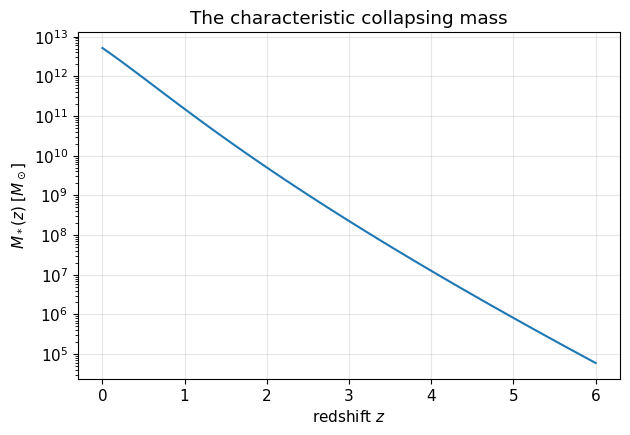

M*(z=0) = 5.175e+12 Msun,  M*(z=6) = 5.989e+04 Msun
sigma(M*) = 1.6756  vs  delta_c = 1.6756


In [4]:
zGrid = np.linspace(0.0, 6.0, 60)
massCollapsing = np.array([criticalOverdensity.collapsingMass(time=timeOf(z)) for z in zGrid])
plt.semilogy(zGrid, massCollapsing)
plt.xlabel('redshift $z$'); plt.ylabel('$M_*(z)$ [$M_\\odot$]')
plt.title('The characteristic collapsing mass')
plt.show()
print(f"M*(z=0) = {massCollapsing[0]:.3e} Msun,  M*(z=6) = {massCollapsing[-1]:.3e} Msun")

# Verify the defining relation sigma(M*, t) = delta_c(t) at z=0.
sigmaAtMStar = cosmologicalMassVariance.rootVariance(massCollapsing[0], ageToday)
deltaC       = criticalOverdensity.value(time=ageToday, mass=massCollapsing[0])
print(f"sigma(M*) = {sigmaAtMStar:.4f}  vs  delta_c = {deltaC:.4f}")
assert np.isclose(sigmaAtMStar, deltaC, rtol=1.0e-3)

## Branching rates: how trees fragment

The Parkinson, Cole & Helly (2008) algorithm — the default tree builder in
Galacticus — gives the probability per unit $\delta_\mathrm{c}$ (the EPS
"time" step) that a halo of mass $M$ splits off a progenitor of mass
$M_\mathrm{branch}$. Its empirical parameters $(G_0, \gamma_1, \gamma_2)$
were calibrated against the Millennium simulation.

The `node` argument allows environment-dependent variants; the standard
algorithm ignores it, so we pass a null handle as in Tutorial 4.

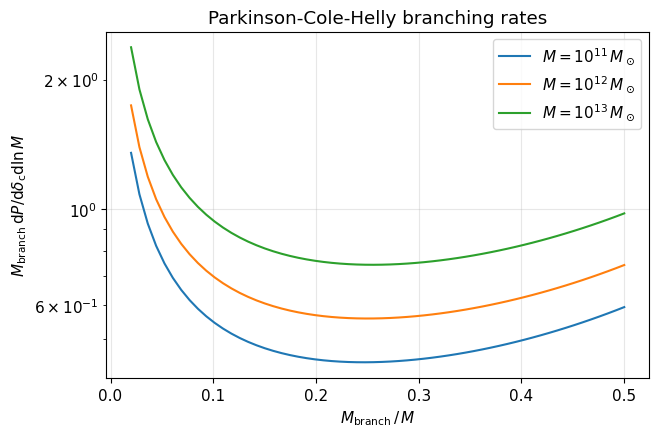

In [5]:
import ctypes
nodeNull = ctypes.c_void_p(0)
branching = galacticus.mergerTreeBranchingProbabilityParkinsonColeHelly(
    0.57, 0.38, -0.01,     # G0, gamma1, gamma2 (Parkinson et al. 2008)
    0.1,                   # accuracy of first-order expansion
    1.0e-6, True,          # hypergeometric-function precision, tabulation
    True, False,           # CDM assumptions; do not tolerate round-off errors
    cosmologicalMassVariance, criticalOverdensity)

deltaCToday = criticalOverdensity.value(time=ageToday, mass=1.0e12)
fig, ax = plt.subplots()
for massParent, color in ((1.0e11, 'C0'), (1.0e12, 'C1'), (1.0e13, 'C2')):
    ratios = np.linspace(0.02, 0.5, 60)          # branch masses up to M/2
    rate = np.array([branching.rate(massParent, deltaCToday, ageToday,
                                    x*massParent, nodeNull) for x in ratios])
    ax.semilogy(ratios, ratios*massParent*rate, color=color,
                label=f'$M = 10^{{{np.log10(massParent):.0f}}}\\,M_\\odot$')
ax.set_xlabel('$M_\\mathrm{branch}\\,/\\,M$')
ax.set_ylabel('$M_\\mathrm{branch}\\,\\mathrm{d}P/\\mathrm{d}\\delta_\\mathrm{c}\\mathrm{d}\\ln M$')
ax.legend(); ax.set_title('Parkinson-Cole-Helly branching rates')
plt.show()

Small progenitors split off far more frequently (the rise toward small
mass ratios), and more massive halos — rarer, higher-$\sigma$ peaks —
branch faster: they assembled more recently.

## What tree building costs

Two more methods expose the mechanics of the tree-build loop:
`probability` is the *total* branching rate above the mass resolution, and
`stepMaximum` the largest $\delta_\mathrm{c}$ step the algorithm permits.
Resolving smaller progenitors makes branchings more frequent and steps
smaller — the classic resolution/cost trade-off of EPS trees.

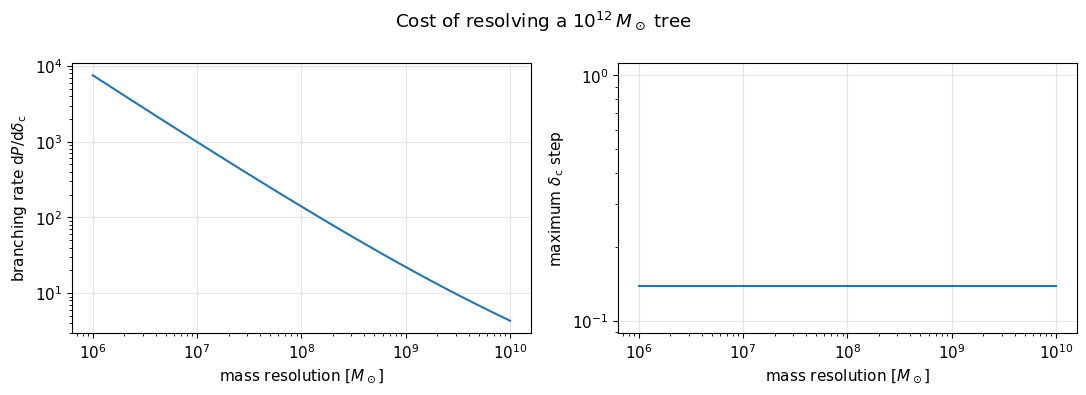

In [6]:
resolutions = np.logspace(6, 10, 24)
massParent  = 1.0e12
total = np.array([branching.probability(massParent, deltaCToday, ageToday, r, nodeNull)
                  for r in resolutions])
steps = np.array([branching.stepMaximum(massParent, deltaCToday, ageToday, r)
                  for r in resolutions])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(resolutions, total)
axes[0].set_xlabel('mass resolution [$M_\\odot$]')
axes[0].set_ylabel('branching rate d$P$/d$\\delta_\\mathrm{c}$')
axes[1].loglog(resolutions, steps)
axes[1].set_xlabel('mass resolution [$M_\\odot$]')
axes[1].set_ylabel('maximum $\\delta_\\mathrm{c}$ step')
fig.suptitle(f'Cost of resolving a $10^{{12}}\\,M_\\odot$ tree')
fig.tight_layout(); plt.show()

## Sampling root halo masses for a tree suite

A Galacticus run needs a *set* of trees whose root masses sample the halo
population. `mergerTreeBuildMasses` implementations decide that sampling;
`construct(time)` returns four arrays at once through the library's
output-array interface — the sampled masses, the mass interval each
represents, and (for weighted samplers) per-tree weights.

Here: masses uniform in $\log M$ over $10^{10}$–$10^{14} M_\odot$ at five
trees per decade.

sampled 20 tree root masses from 1.26e+10 to 7.94e+13 Msun
weight array size: 0


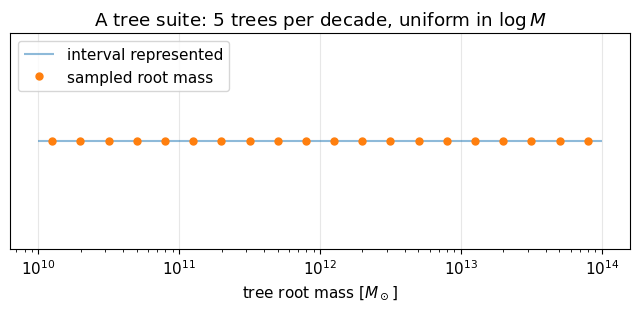

In [7]:
distribution = galacticus.mergerTreeBuildMassDistributionPowerLaw(0.0)  # uniform in log M
buildMasses  = galacticus.mergerTreeBuildMassesSampledDistributionUniform(
    1.0e10, 1.0e14, 5.0, distribution)
mass, massMinimum, massMaximum, weight = buildMasses.construct(ageToday)

print(f"sampled {mass.size} tree root masses from "
      f"{mass.min():.2e} to {mass.max():.2e} Msun")
# This sampler assigns no per-tree weights: the weight array comes back
# empty (each tree instead represents its [massMinimum, massMaximum]
# interval of the mass function).
print(f"weight array size: {weight.size}")

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.hlines(np.ones_like(mass), massMinimum, massMaximum, color='C0', alpha=0.5,
          label='interval represented')
ax.plot(mass, np.ones_like(mass), 'o', color='C1', ms=5, label='sampled root mass')
ax.set_xscale('log'); ax.set_yticks([])
ax.set_xlabel('tree root mass [$M_\\odot$]'); ax.legend(loc='upper left')
ax.set_title('A tree suite: 5 trees per decade, uniform in $\\log M$')
plt.show()

## From building blocks to trees

These are the exact objects a full Galacticus run assembles from a
parameter file to build its trees — the same branching rates, the same
mass samplers. To *grow and evolve* the trees (and the galaxies inside
them) you hand these ingredients to `Galacticus.exe`; see the
`user guide <https://galacticus.readthedocs.io/>`_ for tree-building
parameter files.